In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jeanmidev/smart-meters-in-london/darksky_parameters_documentation.html
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/weather_hourly_darksky.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/acorn_details.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/uk_bank_holidays.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/weather_daily_darksky.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/daily_dataset.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/informations_households.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_97.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_27.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_55.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_0.csv
/kaggle/input/datasets/jeanmi

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# importing a few blocks from daily dataset for analysis
# Unlike half-hourly data, this dataset provides aggregated daily statistics

In [4]:
path = '/kaggle/input/datasets/jeanmidev/smart-meters-in-london/daily_dataset/daily_dataset'

files = os.listdir(path)

dfs = []

for file in files[:5]:   
    if file.endswith('.csv'):
        temp = pd.read_csv(os.path.join(path, file))
        dfs.append(temp)

energy = pd.concat(dfs, ignore_index=True)

In [6]:
energy.head()

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000047,2011-12-08,0.1630,0.160913,0.341,23,0.054238,3.701,0.073
1,MAC000047,2011-12-09,0.1405,0.136979,0.301,48,0.059865,6.575,0.040
2,MAC000047,2011-12-10,0.1050,0.123833,0.327,48,0.064590,5.944,0.035
3,MAC000047,2011-12-11,0.1555,0.140354,0.208,48,0.045387,6.737,0.072
4,MAC000047,2011-12-12,0.1360,0.138021,0.264,48,0.048332,6.625,0.072


In [7]:
energy.shape
energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153653 entries, 0 to 153652
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   LCLid          153653 non-null  object 
 1   day            153653 non-null  object 
 2   energy_median  153651 non-null  float64
 3   energy_mean    153651 non-null  float64
 4   energy_max     153651 non-null  float64
 5   energy_count   153653 non-null  int64  
 6   energy_std     153098 non-null  float64
 7   energy_sum     153651 non-null  float64
 8   energy_min     153651 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 10.6+ MB


In [8]:
energy['day'] = pd.to_datetime(energy['day'])

In [9]:
# sorting according to day for analyzing the pattern
energy = energy.sort_values(by=['LCLid', 'day'])

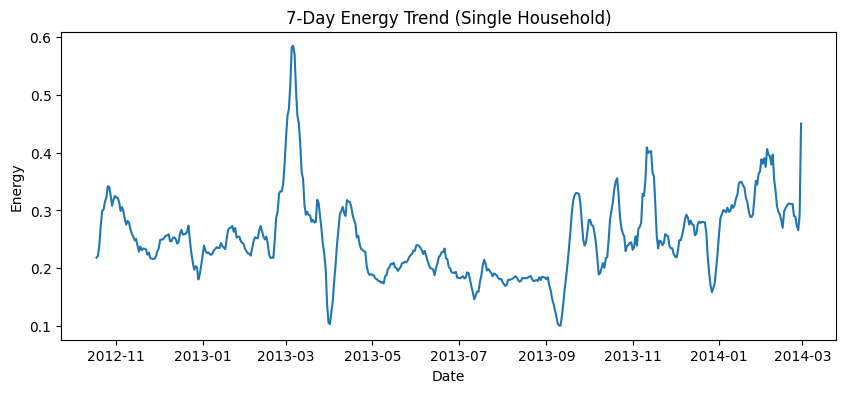

In [18]:
# Visualization for 1st household
sample = energy[energy['LCLid'] == energy['LCLid'].iloc[0]].copy()
sample = sample.sort_values('day')

sample['smooth'] = sample['energy_mean'].rolling(7).mean()

plt.figure(figsize=(10,4))
plt.plot(sample['day'], sample['smooth'])
plt.title("7-Day Energy Trend (Single Household)")
plt.xlabel("Date")
plt.ylabel("Energy")
plt.show()

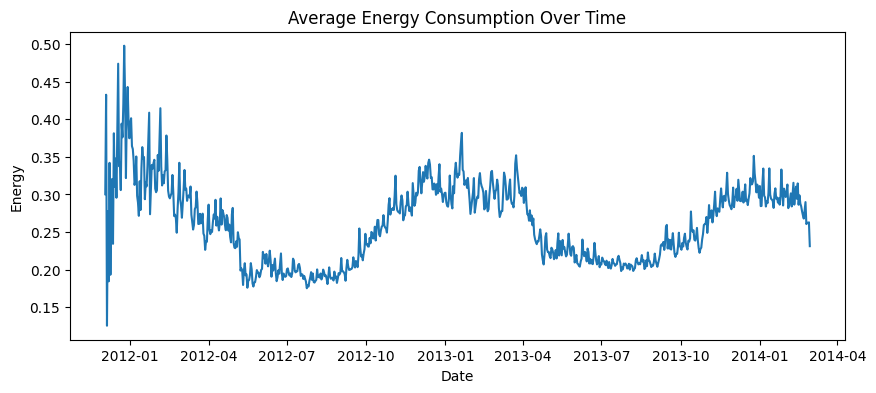

In [11]:
# This clearly shows long-term trends and seasonality, validating time-series modeling
daily_avg = energy.groupby('day')['energy_mean'].mean()

plt.figure(figsize=(10,4))
plt.plot(daily_avg)
plt.title("Overall Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy")
plt.show()

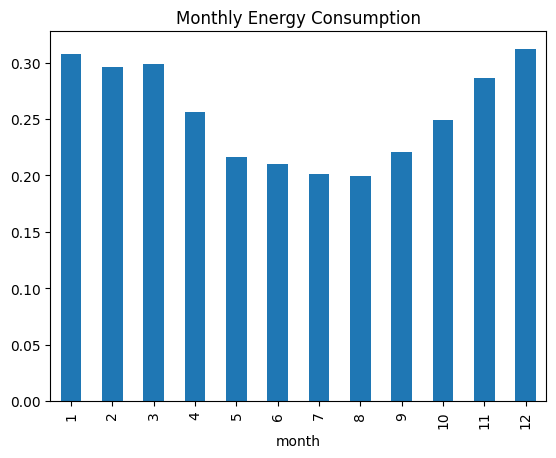

In [13]:
# Energy consumption across months
energy['month'] = pd.to_datetime(energy['day']).dt.month
energy.groupby('month')['energy_mean'].mean().plot(kind='bar')
plt.title("Monthly Energy Consumption")
plt.show()

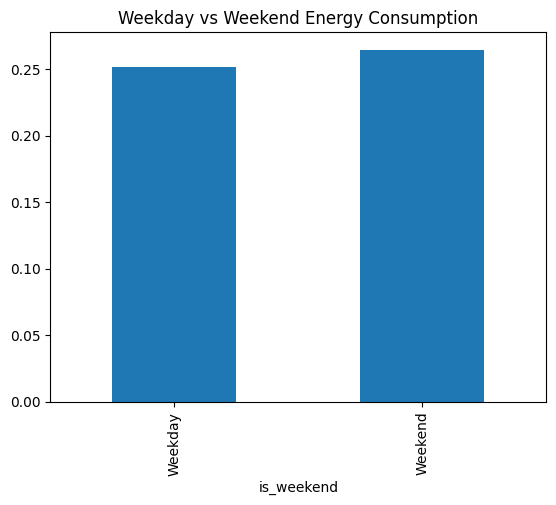

In [17]:
# Energy consumption slightly increases on weekends due to higher home occupancy
energy['is_weekend'] = energy['dayofweek'].apply(lambda x: 1 if x>=5 else 0)

energy.groupby('is_weekend')['energy_mean'].mean().plot(kind='bar')
plt.xticks([0,1], ['Weekday','Weekend'])
plt.title("Weekday vs Weekend Energy Consumption")
plt.show()

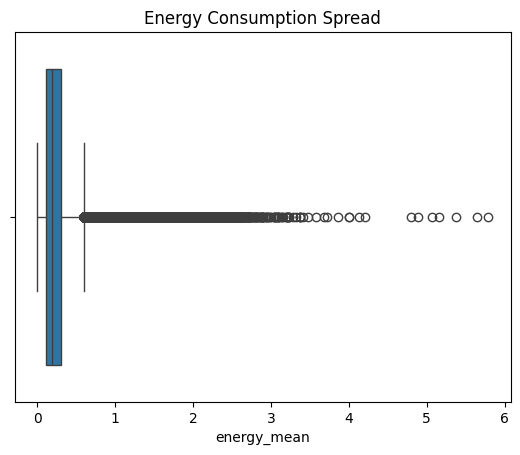

In [15]:
# For variation and outliers
# The data contains significant high-value outliers, representing real high-consumption households rather than noise
sns.boxplot(x=energy['energy_mean'])
plt.title("Energy Consumption Spread")
plt.show()

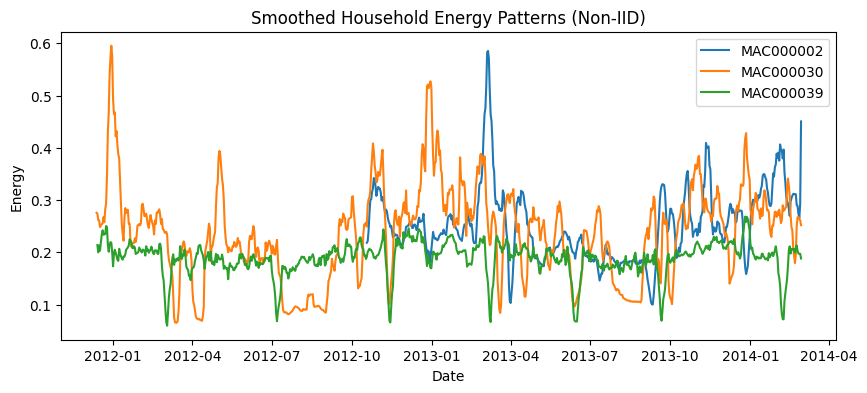

In [22]:
# The consumption patterns differ significantly across households. 
# Proving data heterogeneity (Non-IID), making centralized models ineffective and which motivates federated learning
ids = energy['LCLid'].unique()[:3]

plt.figure(figsize=(10,4))

for i in ids:
    temp = energy[energy['LCLid'] == i].sort_values('day')
    temp['smooth'] = temp['energy_mean'].rolling(7).mean()
    
    plt.plot(temp['day'], temp['smooth'], label=i)

plt.legend()
plt.title("Smoothed Household Energy Patterns (Non-IID)")
plt.xlabel("Date")
plt.ylabel("Energy")
plt.show()